In [2]:
import pandas as pd

# Load the HR dataset
df = pd.read_csv('HR_Employee_Attrition.csv')

# Check the shape of the dataset (rows, columns)
print(f"Dataset Shape: {df.shape}\n")

# Display basic info to check for missing values and data types
df.info()

# Preview the first 5 rows
df.head()

Dataset Shape: (1470, 35)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 1

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
# Drop columns that offer no predictive value
cols_to_drop = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
df = df.drop(columns=cols_to_drop, errors='ignore')

# Convert the target variable 'Attrition' to binary (1 for Yes, 0 for No)
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# Check the class balance of our target variable (percentage)
print(df['Attrition'].value_counts(normalize=True) * 100)

Attrition
0    83.877551
1    16.122449
Name: proportion, dtype: float64


In [4]:
# Convert all categorical text columns into numeric dummy variables
df_encoded = pd.get_dummies(df, drop_first=True)

# Check the new shape (we should have a lot more columns now!)
print(f"Encoded Dataset Shape: {df_encoded.shape}\n")

# Preview the newly encoded data
df_encoded.head()

Encoded Dataset Shape: (1470, 45)



,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,2,94,3,2,4,...,False,False,False,False,False,True,False,False,True,True
1,49,0,279,8,1,3,61,2,2,2,...,False,False,False,False,True,False,False,True,False,False
2,37,1,1373,2,2,4,92,2,1,3,...,True,False,False,False,False,False,False,False,True,True
3,33,0,1392,3,4,4,56,3,1,3,...,False,False,False,False,True,False,False,True,False,True
4,27,0,591,2,1,1,40,3,1,2,...,True,False,False,False,False,False,False,True,False,False


In [5]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df_encoded.drop(columns=['Attrition'])
y = df_encoded['Attrition']

# Split the data (80% for training, 20% for testing)
# We use stratify=y to ensure that the 84/16 class imbalance is maintained in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

Training features shape: (1176, 44)
Testing features shape: (294, 44)


In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Initialize the Random Forest model with balanced class weights
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# Train the model on the training data
rf_model.fit(X_train, y_train)

# Make predictions on the hidden testing data
y_pred = rf_model.predict(X_test)

# Evaluate the model's performance
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred):.2f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

Overall Accuracy: 0.84

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       247
           1       0.44      0.09      0.14        47

    accuracy                           0.84       294
   macro avg       0.65      0.53      0.53       294
weighted avg       0.78      0.84      0.79       294



In [7]:
from imblearn.over_sampling import SMOTE

# 1. Initialize SMOTE and apply it ONLY to the training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# 2. Re-initialize and train the Random Forest on the newly balanced data
rf_model_smote = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model_smote.fit(X_train_smote, y_train_smote)

# 3. Make predictions on the untouched testing data
y_pred_smote = rf_model_smote.predict(X_test)

# 4. Evaluate the new model's performance
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred_smote):.2f}\n")
print("New Classification Report:")
print(classification_report(y_test, y_pred_smote))

Overall Accuracy: 0.82

New Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.94      0.90       247
           1       0.40      0.21      0.28        47

    accuracy                           0.82       294
   macro avg       0.63      0.58      0.59       294
weighted avg       0.79      0.82      0.80       294



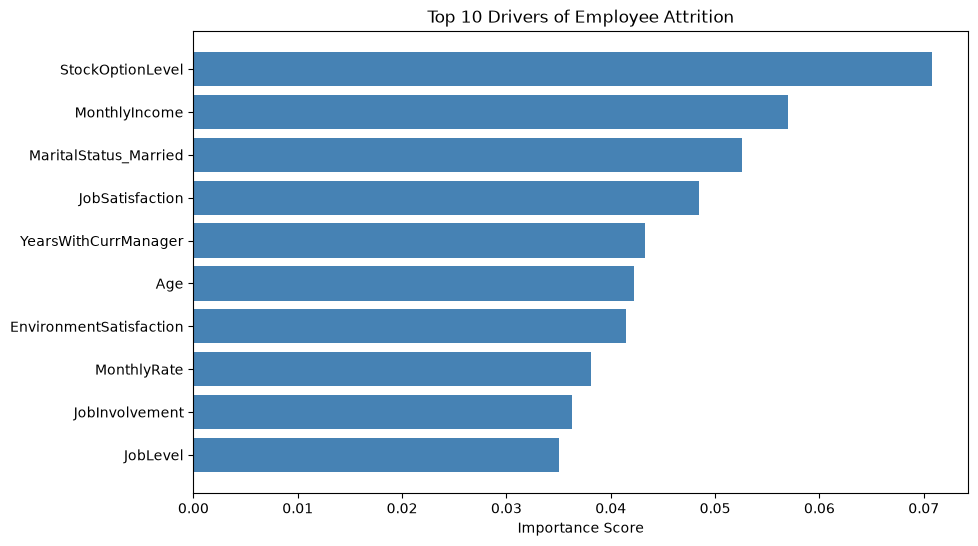

                  Feature  Importance
15       StockOptionLevel    0.070740
9           MonthlyIncome    0.057017
41  MaritalStatus_Married    0.052600
8         JobSatisfaction    0.048410
22   YearsWithCurrManager    0.043296


In [8]:
import matplotlib.pyplot as plt
import pandas as pd

# Extract feature importances from the SMOTE-trained Random Forest
importances = rf_model_smote.feature_importances_
features = X.columns

# Create a sorted DataFrame
feature_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feature_df = feature_df.sort_values(by='Importance', ascending=False)

# Plot the top 10 most important features
plt.figure(figsize=(10, 6))
plt.barh(feature_df['Feature'][:10][::-1], feature_df['Importance'][:10][::-1], color='steelblue')
plt.title('Top 10 Drivers of Employee Attrition')
plt.xlabel('Importance Score')
plt.show()

# Display the top 5 in text
print(feature_df.head(5))

In [9]:
import joblib

# Save the trained Random Forest model
joblib.dump(rf_model_smote, 'hr_model.pkl')

# Save the exact list of feature columns (crucial for Streamlit)
joblib.dump(list(X.columns), 'model_features.pkl')

print("Model and features exported successfully!")

Model and features exported successfully!
